### Convolutional Neural Network for Dustbin Image Classification

In [ ]:
# 1. Imports and Data Loading
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

#### Data Generator Setup
This configures the `ImageDataGenerator` to load and preprocess images from your Google Drive for training. Make sure your `dustbin` directory contains subdirectories named after your classes (e.g., 'test', 'train').

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/dustbin',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 415 images belonging to 2 classes.


#### Displaying Class Indices
It's crucial to know the mapping of class names to integer indices that `ImageDataGenerator` uses, as this dictates how you interpret your model's output.

In [ ]:
print('Class indices:', train_data.class_indices)

Class indices: {'test': 0, 'train': 1}


### 2. Model Definition
Here, a Sequential Convolutional Neural Network (CNN) is defined. It includes convolutional layers for feature extraction, max pooling for downsampling, flattening to prepare data for dense layers, and dense layers for classification. The final dense layer has 2 units and a 'softmax' activation for categorical classification, matching the number of classes found in your training data.

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')  # 2 units for 2 classes, softmax for categorical
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 3. Model Compilation and Training
The model is compiled with the Adam optimizer, 'categorical_crossentropy' loss function (suitable for multi-class classification), and 'accuracy' as a metric. It's then trained on your preprocessed image data for 10 epochs.

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_data, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.6819 - loss: 2.6623
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.8120 - loss: 0.5639
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.8072 - loss: 0.4563
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.8651 - loss: 0.3447
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.9181 - loss: 0.2534
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 271ms/step - accuracy: 0.9542 - loss: 0.1541
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.9614 - loss: 0.1214
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.9880 - loss: 0.0664
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - accuracy: 0.9880 - loss: 0.0469
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 269ms/step - accuracy: 0.9928 - loss: 0.0308


### 4. Image Upload and Preprocessing for Prediction
This section allows you to upload an image for prediction and preprocesses it to match the input requirements of your trained CNN model (resizing, normalization, reshaping).

In [ ]:
# Upload a new image for prediction
uploaded = files.upload()

# Assuming only one file is uploaded, get its name
image_filename = list(uploaded.keys())[0]

# Load and preprocess the image
img = cv2.imread(image_filename)
img = cv2.resize(img, (224, 224))   # Resize to target size (224, 224)
img = img / 255.0                    # Normalize pixel values
img = np.reshape(img, (1, 224, 224, 3)) # Reshape for model input (batch_size, height, width, channels)

Saving test5.jpeg to test5.jpeg


### 5. Make and Display Prediction
Here, the preprocessed image is fed into the trained model to get a prediction. The `class_index` is determined using `np.argmax` on the prediction probabilities, and then mapped back to a human-readable label using the `labels` list, which is derived from your `train_data.class_indices`.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction: empty


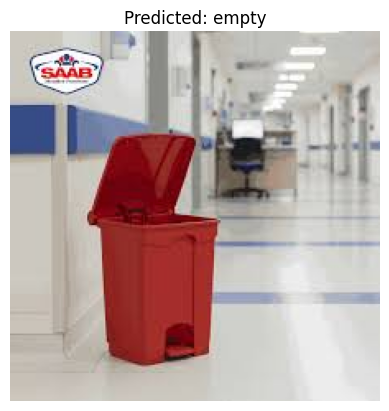

In [ ]:
prediction = model.predict(img)
class_index = np.argmax(prediction)

# Map the trained class indices ('test', 'train') to the desired display labels ('empty', 'full')
# Assuming 'test' (index 0) maps to 'empty' and 'train' (index 1) maps to 'full'.
labels_for_display = ['empty', 'full']

result = labels_for_display[class_index]
print(f"Prediction: {result}")

# Display the image with the prediction title
plt.imshow(cv2.cvtColor(cv2.imread(image_filename), cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {result}")
plt.axis('off')
plt.show()

In [ ]:
print(train_data.class_indices)


{'test': 0, 'train': 1}


In [ ]:
model.save("dustbin_model.h5")